# Лабораторная работа №2
## Метод ломаных (метод Пиявского)

**Цель работы:** изучить метод ломаных и реализовать алгоритм поиска глобального минимума липшицевой функции на заданном отрезке.

В качестве тестовой функции используется одномерная функция Растригина:

\[
f(x) = x^2 - 10\cos(2\pi x) + 10
\]

Рассматриваемый отрезок:

\[
[-5.12; 5.12]
\]

На данном отрезке функция имеет несколько локальных минимумов, поэтому подходит для проверки метода глобальной оптимизации.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

Matplotlib is building the font cache; this may take a moment.


In [2]:
def f(x):
    return x**2 - 10 * np.cos(2 * np.pi * x) + 10

In [3]:
a = -5.12
b = 5.12
eps = 0.01

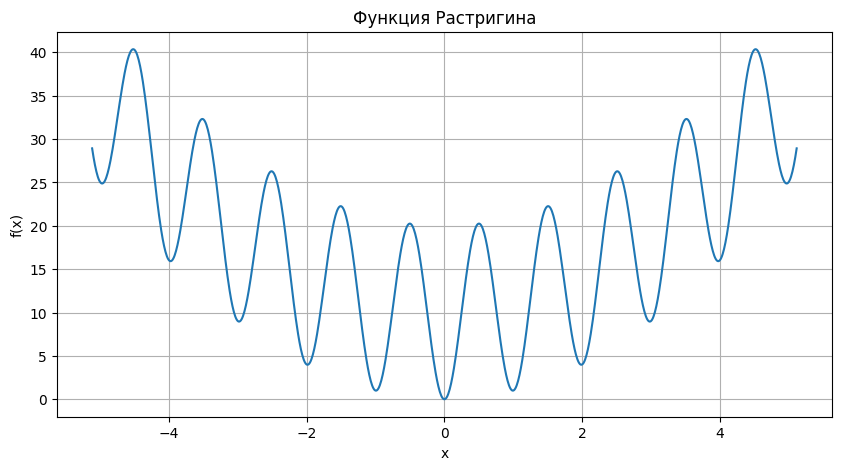

In [4]:
x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Функция Растригина")
plt.grid()
plt.show()

### Оценка константы Липшица

Функция \(W(x)\) называется липшицевой на отрезке \([a,b]\), если существует константа \(L > 0\), такая что для любых \(u,v \in [a,b]\) выполняется:

$$
|W(u)-W(v)| \leq L|u-v|.
$$

Константа \(L\) называется константой Липшица.

Для численной оценки константы Липшица вычислим отношения приращения функции к приращению аргумента:

$$
L \approx \max_i
\left|
\frac{W(x_{i+1})-W(x_i)}
{x_{i+1}-x_i}
\right|.
$$

Для надежности полученную оценку увеличим на 20%.

In [5]:
x_lipschitz = np.linspace(a, b, 10001)
y_lipschitz = f(x_lipschitz)

slopes = np.abs(
    (y_lipschitz[1:] - y_lipschitz[:-1]) /
    (x_lipschitz[1:] - x_lipschitz[:-1])
)

L_est = np.max(slopes)
L = 1.2 * L_est

print("Оценка константы Липшица:", L_est)
print("Константа Липшица с запасом:", L)

Оценка константы Липшица: 71.33241616759473
Константа Липшица с запасом: 85.59889940111367


### Начальные точки метода

На начальном этапе используются две верхние вершины, совпадающие с концами рассматриваемого отрезка:

$$
u_0 = a, \qquad u_1 = b.
$$

Значения функции в этих точках:

$$
W(u_0), \qquad W(u_1).
$$

Между двумя верхними вершинами строятся элементы миноранты. Координата их точки пересечения вычисляется по формуле:

$$
u_{cross} =
\frac{W(u_0)-W(u_1)}{2L}
+
\frac{u_0+u_1}{2}.
$$

Полученная точка является первой нижней вершиной ломаной.

In [7]:
u0 = a
u1 = b

w0 = f(u0)
w1 = f(u1)

u_cross = (w0 - w1) / (2 * L) + (u0 + u1) / 2
print("u0 =", u0)
print("W(u0) =", w0)

print("u1 =", u1)
print("W(u1) =", w1)

print("Первая нижняя вершина u_cross =", u_cross)

u0 = -5.12
W(u0) = 28.924713725785896
u1 = 5.12
W(u1) = 28.924713725785896
Первая нижняя вершина u_cross = 0.0


In [8]:
y_cross = w0 - L * abs(u_cross - u0)

print("Y-координата нижней вершины =", y_cross)

Y-координата нижней вершины = -409.3416512079161


In [9]:
u2 = u_cross
w2 = f(u2)

print("u2 =", u2)
print("W(u2) =", w2)

u2 = 0.0
W(u2) = 0.0


### Построение новой вспомогательной функции

После нахождения точки \(u_2\) вычисляется значение исходной функции \(W(u_2)\).

В этой точке строится новая вспомогательная функция:

$$
g_2(x,u_2)=W(u_2)-L|x-u_2|.
$$

Первая ломаная задается как

$$
p_1(x)=\max\{g_0(x,u_0),g_1(x,u_1)\}.
$$

После добавления точки \(u_2\) получаем новую ломаную:

$$
p_2(x)=\max\{p_1(x),g_2(x,u_2)\}.
$$

In [10]:
def g(x, u):
    return f(u) - L * np.abs(x - u)

g0 = g(x, u0)
g1 = g(x, u1)
g2 = g(x, u2)

p1 = np.maximum(g0, g1)
p2 = np.maximum(p1, g2)

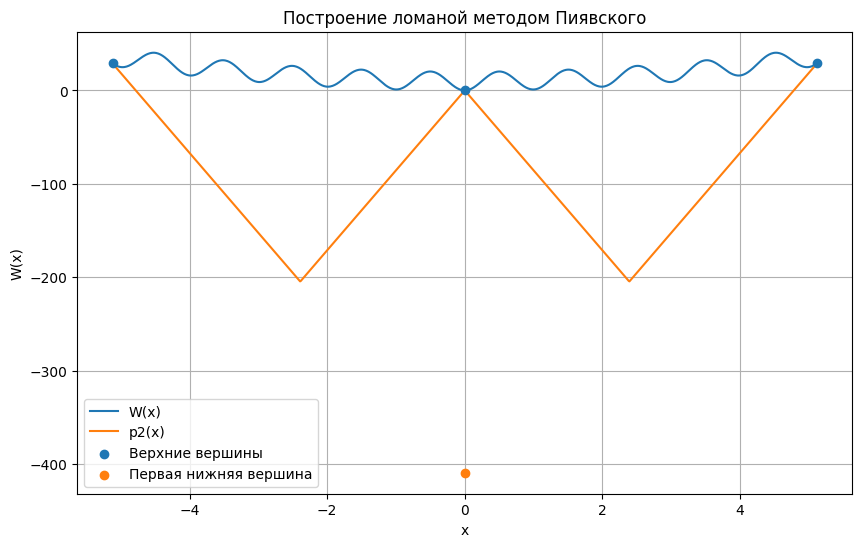

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(x, f(x), label="W(x)")
plt.plot(x, p2, label="p2(x)")

plt.scatter(
    [u0, u1, u2],
    [w0, w1, w2],
    zorder=5,
    label="Верхние вершины"
)

plt.scatter(
    [u_cross],
    [y_cross],
    zorder=5,
    label="Первая нижняя вершина"
)

plt.xlabel("x")
plt.ylabel("W(x)")
plt.title("Построение ломаной методом Пиявского")
plt.grid()
plt.legend()
plt.show()

### Вычисление новых нижних вершин

После добавления верхней вершины \(u_2\) исходный отрезок разбивается на два:

$$
[u_0,u_2]
$$

и

$$
[u_2,u_1].
$$

Для каждого из них вычисляется новая нижняя вершина ломаной по формуле:

$$
u_{cross}=
\frac{W(u_q)-W(u_v)}{2L}
+
\frac{u_q+u_v}{2}.
$$

Таким образом получаем две нижние вершины: слева и справа от \(u_2\).

In [12]:
u_left = (w0 - w2) / (2 * L) + (u0 + u2) / 2
u_right = (w2 - w1) / (2 * L) + (u2 + u1) / 2

y_left = w0 - L * abs(u_left - u0)
y_right = w2 - L * abs(u_right - u2)

print("Левая нижняя вершина:")
print("x =", u_left)
print("y =", y_left)

print()

print("Правая нижняя вершина:")
print("x =", u_right)
print("y =", y_right)

Левая нижняя вершина:
x = -2.3910450605781413
y = -204.67082560395806

Правая нижняя вершина:
x = 2.3910450605781413
y = -204.67082560395806


### Выбор следующей пробной точки

На каждой итерации в качестве следующей пробной точки выбирается нижняя вершина ломаной с минимальным значением.

В данном случае левая и правая нижние вершины имеют одинаковые значения, поэтому выбираем левую вершину:

$$
u_3 = u_{left}.
$$

После этого вычисляем значение исходной функции в новой точке:

$$
W(u_3).
$$

In [13]:
u3 = u_left
w3 = f(u3)

print("Следующая пробная точка u3 =", u3)
print("W(u3) =", w3)

Следующая пробная точка u3 = -2.3910450605781413
W(u3) = 23.463917730968962


In [22]:
def piyavsky_method(f, a, b, L, eps, max_iter=1000):
    points = [
        [a, f(a)],
        [b, f(b)]
    ]

    iterations = 0

    while iterations < max_iter:
        points.sort(key=lambda point: point[0])

        lower_vertices = []

        for i in range(len(points) - 1):
            u_left, w_left = points[i]
            u_right, w_right = points[i + 1]

            u_cross = (
                (w_left - w_right) / (2 * L)
                + (u_left + u_right) / 2
            )

            y_cross = w_left - L * abs(u_cross - u_left)

            lower_vertices.append(
                [u_cross, y_cross]
            )

        u_new, y_new = min(
            lower_vertices,
            key=lambda point: point[1]
        )

        w_new = f(u_new)

        iterations += 1

        if w_new - y_new < eps:
            points.append([u_new, w_new])

            return {
                "x_min": u_new,
                "f_min": w_new,
                "iterations": iterations,
                "error": w_new - y_new,
                "points": points,
                "lower_vertices": lower_vertices
            }

        points.append([u_new, w_new])

    return {
    "x_min": u_new,
    "f_min": w_new,
    "iterations": iterations,
    "error": w_new - y_new,
    "points": points,
    "lower_vertices": lower_vertices
}

In [23]:
start_time = time.perf_counter()

result = piyavsky_method(
    f=f,
    a=a,
    b=b,
    L=L,
    eps=eps
)

end_time = time.perf_counter()

elapsed_time = end_time - start_time

In [27]:
print("Результат работы метода Пиявского")
print()
print(f"Найденный аргумент x* = {result['x_min']:.6f}")
print(f"Значение функции W(x*) = {result['f_min']:.6f}")
print(f"Количество итераций = {result['iterations']}")
print(f"Достигнутая точность = {result['error']:.6f}")
print(f"Время работы = {elapsed_time:.6f} сек")

Результат работы метода Пиявского

Найденный аргумент x* = -0.000077
Значение функции W(x*) = 0.000001
Количество итераций = 200
Достигнутая точность = 0.006588
Время работы = 0.015232 сек


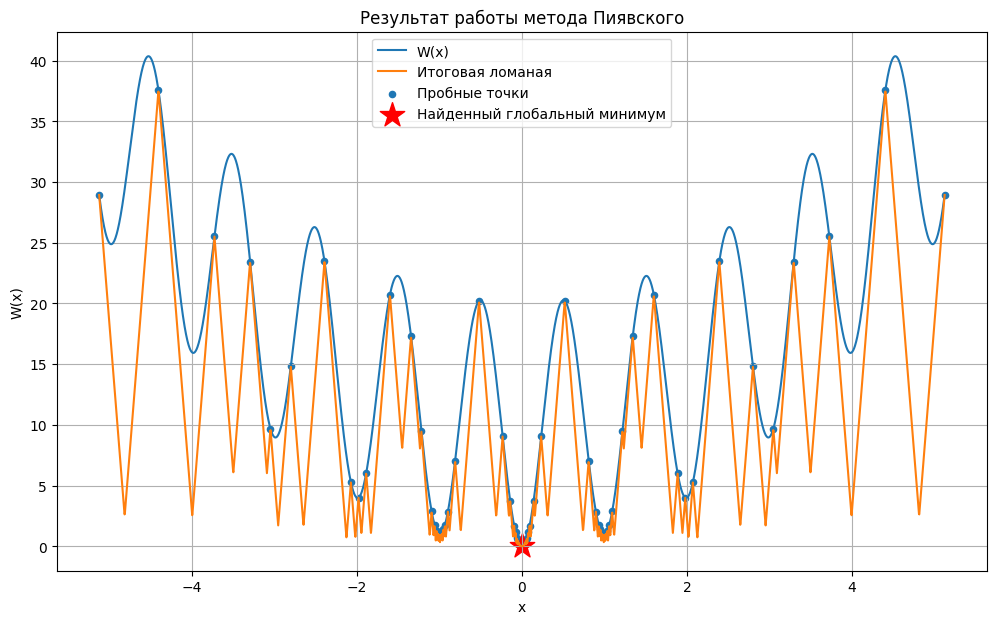

In [30]:
points = sorted(result["points"], key=lambda point: point[0])

upper_x = np.array([point[0] for point in points])
upper_y = np.array([point[1] for point in points])

x_plot = np.linspace(a, b, 3000)

minorant = np.full_like(x_plot, -np.inf)

for u, w in points:
    g_values = w - L * np.abs(x_plot - u)
    minorant = np.maximum(minorant, g_values)

plt.figure(figsize=(12, 7))

plt.plot(x_plot, f(x_plot), label="W(x)")
plt.plot(x_plot, minorant, label="Итоговая ломаная")

plt.scatter(
    upper_x,
    upper_y,
    s=20,
    label="Пробные точки"
)

plt.scatter(
    result["x_min"],
    result["f_min"],
    s=340,
    marker="*",
    color="red",
    label="Найденный глобальный минимум"
)

plt.xlabel("x")
plt.ylabel("W(x)")
plt.title("Результат работы метода Пиявского")
plt.grid()
plt.legend()
plt.show()

### Результат работы алгоритма

В результате работы метода Пиявского был найден приближенный глобальный минимум функции Растригина на отрезке \([-5.12; 5.12]\).

Получено:

$$
x^* \approx -0.000077,
$$

$$
W(x^*) \approx 0.000001.
$$

Полученное значение близко к точному глобальному минимуму функции Растригина:

$$
x^* = 0, \qquad W(x^*) = 0.
$$

Для достижения заданной точности \(\varepsilon = 0.01\) потребовалось 200 итераций.

Достигнутая точность составила приблизительно:

$$
0.00659 < 0.01.
$$

На графике показаны исходная функция, построенная методом Пиявского ломаная, пробные точки алгоритма и найденная точка глобального минимума.

### Вывод

В ходе лабораторной работы был реализован метод ломаных (метод Пиявского) для поиска глобального минимума липшицевой функции на заданном отрезке.

Работа алгоритма была проверена на функции Растригина, имеющей несколько локальных минимумов. Метод позволил найти точку, близкую к известному глобальному минимуму функции.

Полученный результат подтверждает корректность реализации метода Пиявского при заданной точности вычислений.